   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 5.0 MB/s eta 0:00:00
--- ՔԱՅԼ 1. ՎԵՐԲԵՌՆԵՔ ՍՈՎՈՐԵԼՈՒ ՖԱՅԼԵՐԸ ---


Saving ԱԿՍԵԼ ԲԱԿՈՒՆՑ ԿԱՐՄՐԱՔԱՐ.docx to ԱԿՍԵԼ ԲԱԿՈՒՆՑ ԿԱՐՄՐԱՔԱՐ.docx
Saving ԵՂԻՇԵ ՉԱՐԵՆՑ ԵՐԿԻՐ ՆԱԻՐԻ ԱԲ.docx to ԵՂԻՇԵ ՉԱՐԵՆՑ ԵՐԿԻՐ ՆԱԻՐԻ ԱԲ.docx
Saving ԽԱՉԱՏՈՒՐ ԱԲՈՎՅԱՆ ՎԵՐՔ ՀԱՅԱՍՏԱՆԻ ԳԼՈՒԽ 1.docx to ԽԱՉԱՏՈՒՐ ԱԲՈՎՅԱՆ ՎԵՐՔ ՀԱՅԱՍՏԱՆԻ ԳԼՈՒԽ 1.docx
Saving ՄՈՒՐԱՑԱՆ ԳևՈՐԳ ՄԱՐԶՊԵՏՈՒՆԻ Ա-Է.docx to ՄՈՒՐԱՑԱՆ ԳևՈՐԳ ՄԱՐԶՊԵՏՈՒՆԻ Ա-Է.docx
Saving ՇԻՐՎԱՆԶԱԴԵ ՉԱՐ ՈԳԻ 1-10.docx to ՇԻՐՎԱՆԶԱԴԵ ՉԱՐ ՈԳԻ 1-10.docx
Saving ՐԱՖՖԻ ԽԵՆԹԸ ՄԻՆՉև ԺԷ.docx to ՐԱՖՖԻ ԽԵՆԹԸ ՄԻՆՉև ԺԷ.docx

--- ՔԱՅԼ 2. ՎԵՐԲԵՌՆԵՔ ԲՈԼՈՐ ՍՏՈՒԳՎՈՂ ՖԱՅԼԵՐԸ ---


Saving Ալինա 1-6.docx to Ալինա 1-6.docx
Saving Առաջին սերը.docx to Առաջին սերը.docx
Saving Երևանի ուղղիչ տնից 2-6.docx to Երևանի ուղղիչ տնից 2-6.docx
Saving Խաչագողի հիշատակարանը Ա.docx to Խաչագողի հիշատակարանը Ա.docx
Saving Կյորես.docx to Կյորես.docx
Saving Նոյի ագռավ.docx to Նոյի ագռավ.docx


,Ֆայլ,Բակունց,Չարենց,Աբովյան,Մուրացան,Շիրվանզադե,Րաֆֆի,Կանխատեսում
0,Ալինա 1-6.docx,-3.096212,-3.093693,-3.128107,-3.092083,-3.089221,-3.089609,Շիրվանզադե
1,Առաջին սերը.docx,-3.067712,-3.087138,-3.055784,-3.097359,-3.070772,-3.076068,Աբովյան
2,Երևանի ուղղիչ տնից 2-6.docx,-3.082419,-3.076911,-3.109618,-3.085521,-3.077587,-3.076230,Րաֆֆի
3,Խաչագողի հիշատակարանը Ա.docx,-3.072228,-3.074638,-3.095585,-3.076013,-3.069278,-3.068047,Րաֆֆի
4,Կյորես.docx,-3.086518,-3.088990,-3.118164,-3.096909,-3.086480,-3.085287,Րաֆֆի
5,Նոյի ագռավ.docx,-3.116311,-3.109543,-3.153047,-3.110255,-3.113026,-3.110112,Չարենց


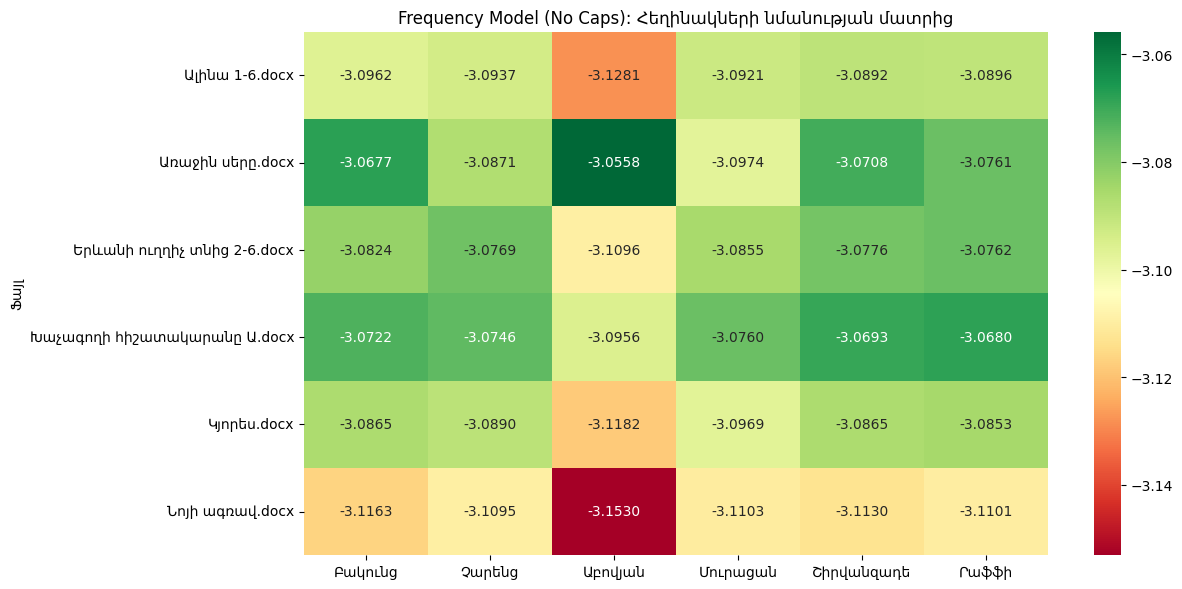

In [1]:
import math
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files

!pip install python-docx
from docx import Document

# Կարգավորումներ (Այբուբենը միայն փոքրատառերով է)
alphabet = ' աբգդեզէըթժիլխծկհձղճմյնշոչպջռսվտրցւփքևօֆ'
n, alpha = len(alphabet), 1e-4
authors_to_find = ["Աբովյան", "Րաֆֆի", "Բակունց", "Շիրվանզադե", "Չարենց", "Մուրացան"]

def read_docx(filename):
    return " ".join([p.text for p in Document(filename).paragraphs])

def text_processing(text):
    # Հեռացվել է .lower() հրահանգը:
    # Մեծատառերը չեն փոխարինվում փոքրատառերով, այլ ուղղակի չեն անցնում ֆիլտրը:
    tx = text.replace("ու", "ւ")
    clean = ''.join([x for x in tx if x in alphabet])
    return " " + " ".join(clean.split()) + " "

def get_freq_model(text):
    N = len(text)
    return [(text.count(ch) + alpha) / (N + alpha * n) for ch in alphabet]

def frequency_score(test_text, model_probs):
    if len(test_text) == 0: return -1e10
    return sum(math.log(model_probs[alphabet.index(ch)]) for ch in test_text) / len(test_text)

# 1. ՍՈՎՈՐԵԼՈՒ ՓՈՒԼ
print("--- ՔԱՅԼ 1. ՎԵՐԲԵՌՆԵՔ ՍՈՎՈՐԵԼՈՒ ՖԱՅԼԵՐԸ ---")
uploaded_train = files.upload()
author_files = {auth: fname for fname in uploaded_train.keys() for auth in authors_to_find if auth.lower() in fname.lower()}
freq_models = {name: get_freq_model(text_processing(read_docx(fname))) for name, fname in author_files.items()}

# 2. ԹԵՍՏԱՎՈՐՄԱՆ ՓՈՒԼ
print("\n--- ՔԱՅԼ 2. ՎԵՐԲԵՌՆԵՔ ԲՈԼՈՐ ՍՏՈՒԳՎՈՂ ՖԱՅԼԵՐԸ ---")
uploaded_tests = files.upload()
all_results = []

for test_filename in uploaded_tests.keys():
    test_text = text_processing(read_docx(test_filename))
    res_row = {'Ֆայլ': test_filename}
    for name, probs in freq_models.items():
        res_row[name] = frequency_score(test_text, probs)
    scores_only = {k: v for k, v in res_row.items() if k != 'Ֆայլ'}
    res_row['Կանխատեսում'] = max(scores_only, key=scores_only.get)
    all_results.append(res_row)

# 3. ՎԻԶՈՒԱԼԻԶԱՑԻԱ
df_res = pd.DataFrame(all_results)
display(df_res)
heatmap_df = df_res.set_index('Ֆայլ').drop(columns=['Կանխատեսում'])
plt.figure(figsize=(12, len(all_results) * 0.8 + 2))
sns.heatmap(heatmap_df, annot=True, cmap="RdYlGn", fmt=".4f")
plt.title("Frequency Model (No Caps): Հեղինակների նմանության մատրից")
plt.show()